# Assignment 8: Building a Variational Autoencoder and Visualising Its Latent Space

## Objective
Build a Variational Autoencoder (VAE) using MNIST with a **2-dimensional latent space**, train it for approximately 20 epochs, record reconstruction and KL-divergence losses, visualize the latent space, and decode points across the latent space.

#Name: Soham Sen
#Class: BCA Sem 5
#Reg No: 2411021240008

## 1. Imports and Device

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
Device: cuda
GPU: Tesla T4


## 2. Load MNIST

In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 508kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.18MB/s]

Training samples: 60000
Test samples: 10000


## 3. Define the VAE

The encoder produces a mean (`mu`) and log-variance (`logvar`) for a 2D latent distribution. The reparameterization step samples a latent vector, and the decoder reconstructs the image.

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)
        self.fc2 = nn.Linear(latent_dim, 256)
        self.fc3 = nn.Linear(256, 784)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return torch.sigmoid(self.fc3(F.relu(self.fc2(z))))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

vae = VAE(2).to(device)
print(vae)

VAE(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc_mu): Linear(in_features=256, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=2, bias=True)
  (fc2): Linear(in_features=2, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=784, bias=True)
)


## 4. VAE Loss

In [ ]:
def vae_loss(reconstruction, x, mu, logvar):
    reconstruction_loss = F.binary_cross_entropy(
        reconstruction, x, reduction="sum"
    )
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    return reconstruction_loss + kl_loss, reconstruction_loss, kl_loss

optimizer = optim.Adam(vae.parameters(), lr=1e-3)

reconstruction_losses = []
kl_losses = []
total_losses = []

## 5. Train for 20 Epochs

In [ ]:
num_epochs = 20

for epoch in range(1, num_epochs + 1):
    vae.train()
    total_recon = total_kl = total_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device).view(images.size(0), -1)

        optimizer.zero_grad()
        reconstruction, mu, logvar = vae(images)

        loss, recon, kl = vae_loss(reconstruction, images, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()

    n = len(train_loader.dataset)
    avg_recon = total_recon / n
    avg_kl = total_kl / n
    avg_total = total_loss / n

    reconstruction_losses.append(avg_recon)
    kl_losses.append(avg_kl)
    total_losses.append(avg_total)

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"Reconstruction: {avg_recon:.4f} | "
        f"KL: {avg_kl:.4f} | Total: {avg_total:.4f}"
    )

Epoch 01/20 | Reconstruction: 189.9440 | KL: 6.5210 | Total: 196.4650
Epoch 02/20 | Reconstruction: 163.8021 | KL: 5.1317 | Total: 168.9338
Epoch 03/20 | Reconstruction: 159.6296 | KL: 5.2078 | Total: 164.8374
Epoch 04/20 | Reconstruction: 157.3921 | KL: 5.3038 | Total: 162.6959
Epoch 05/20 | Reconstruction: 155.7204 | KL: 5.4048 | Total: 161.1251
Epoch 06/20 | Reconstruction: 154.2563 | KL: 5.4674 | Total: 159.7237
Epoch 07/20 | Reconstruction: 152.9756 | KL: 5.5443 | Total: 158.5199
Epoch 08/20 | Reconstruction: 151.9008 | KL: 5.6060 | Total: 157.5068
Epoch 09/20 | Reconstruction: 150.9531 | KL: 5.6556 | Total: 156.6086
Epoch 10/20 | Reconstruction: 150.1002 | KL: 5.6938 | Total: 155.7940
Epoch 11/20 | Reconstruction: 149.3716 | KL: 5.7259 | Total: 155.0975
Epoch 12/20 | Reconstruction: 148.6868 | KL: 5.7829 | Total: 154.4697
Epoch 13/20 | Reconstruction: 148.1023 | KL: 5.8164 | Total: 153.9187
Epoch 14/20 | Reconstruction: 147.5733 | KL: 5.8409 | Total: 153.4141
Epoch 15/20 | Recons

## 6. Plot Reconstruction and KL-Divergence Loss

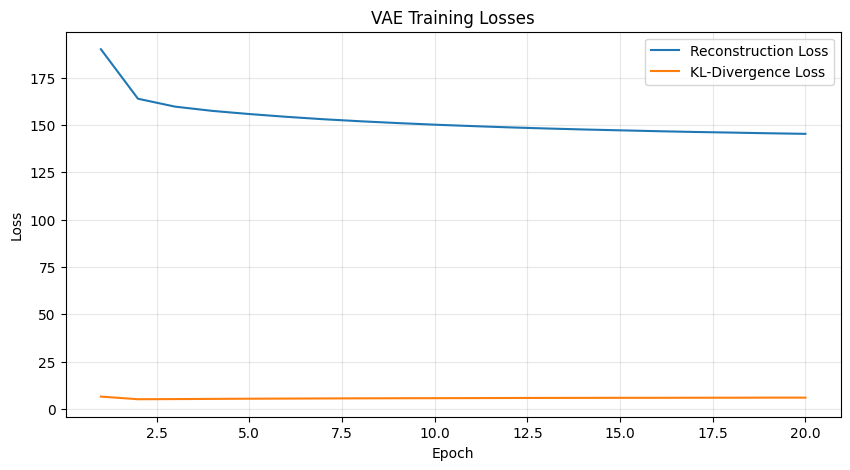

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, reconstruction_losses, label="Reconstruction Loss")
plt.plot(epochs, kl_losses, label="KL-Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Losses")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Encode Test Images and Visualise the 2D Latent Space

The encoder's mean (`mu`) is used as the coordinate for each test image. Points are colored according to the true digit label.

In [ ]:
vae.eval()

latent_points = []
latent_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device).view(images.size(0), -1)
        mu, logvar = vae.encode(images)
        latent_points.append(mu.cpu().numpy())
        latent_labels.append(labels.numpy())

latent_points = np.concatenate(latent_points)
latent_labels = np.concatenate(latent_labels)

print("Latent representation:", latent_points.shape)

Latent representation: (10000, 2)


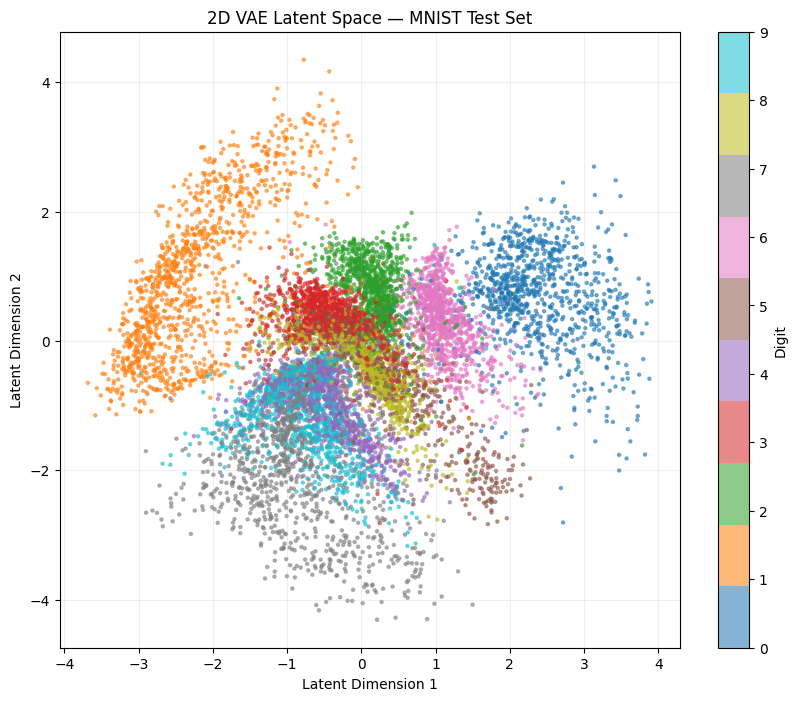

In [ ]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    latent_points[:, 0],
    latent_points[:, 1],
    c=latent_labels,
    cmap="tab10",
    s=5,
    alpha=0.55
)
plt.colorbar(scatter, ticks=range(10), label="Digit")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("2D VAE Latent Space — MNIST Test Set")
plt.grid(alpha=0.2)
plt.show()

## 8. Decode Points Across the Latent Space

Points from approximately **−3 to +3** are decoded into images. Neighboring latent coordinates can be compared to study whether generated digits change smoothly.

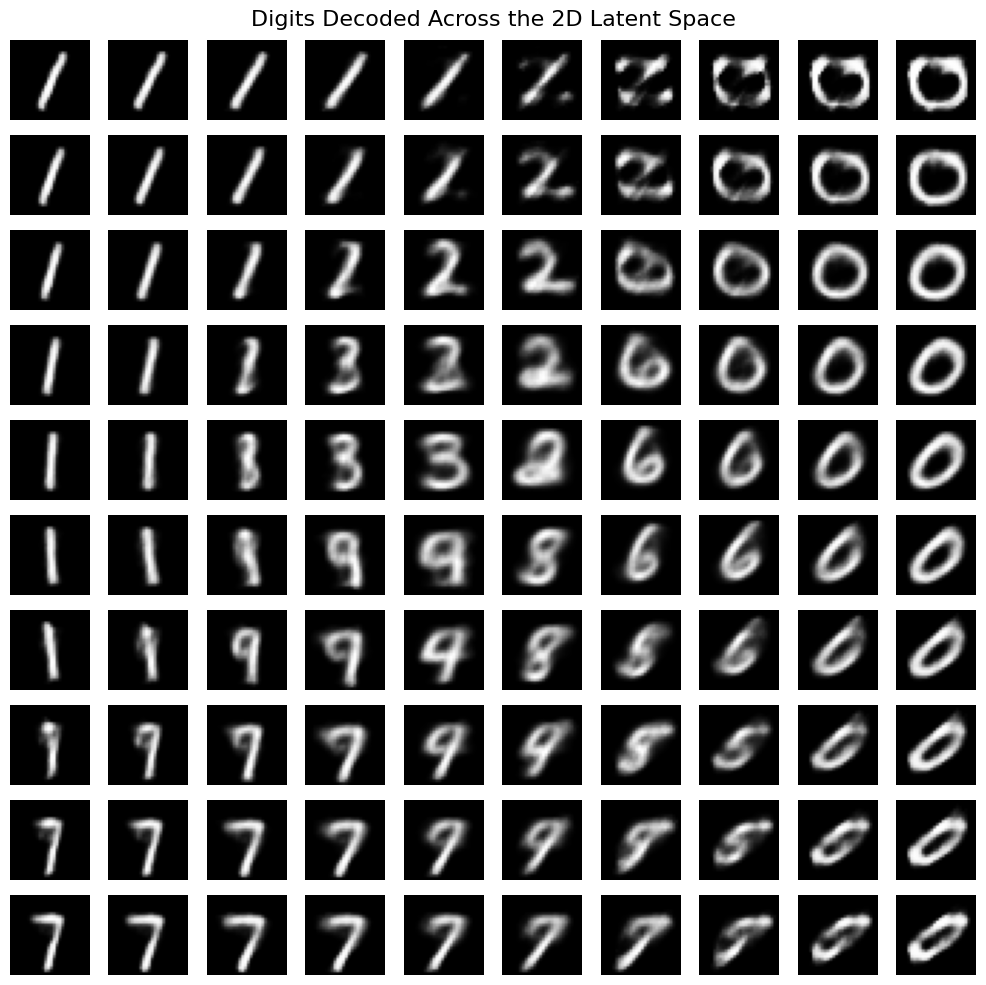

In [ ]:
values = np.linspace(-3, 3, 10)

coords = [[x, y] for y in reversed(values) for x in values]
z_grid = torch.tensor(coords, dtype=torch.float32, device=device)

with torch.no_grad():
    decoded = vae.decode(z_grid).cpu().numpy()

decoded = decoded.reshape(10, 10, 28, 28)

fig, axes = plt.subplots(10, 10, figsize=(10, 10))
for r in range(10):
    for c in range(10):
        axes[r, c].imshow(decoded[r, c], cmap="gray")
        axes[r, c].axis("off")

plt.suptitle("Digits Decoded Across the 2D Latent Space", fontsize=16)
plt.tight_layout()
plt.show()

## 9. Smaller 5 × 5 Decoded Grid

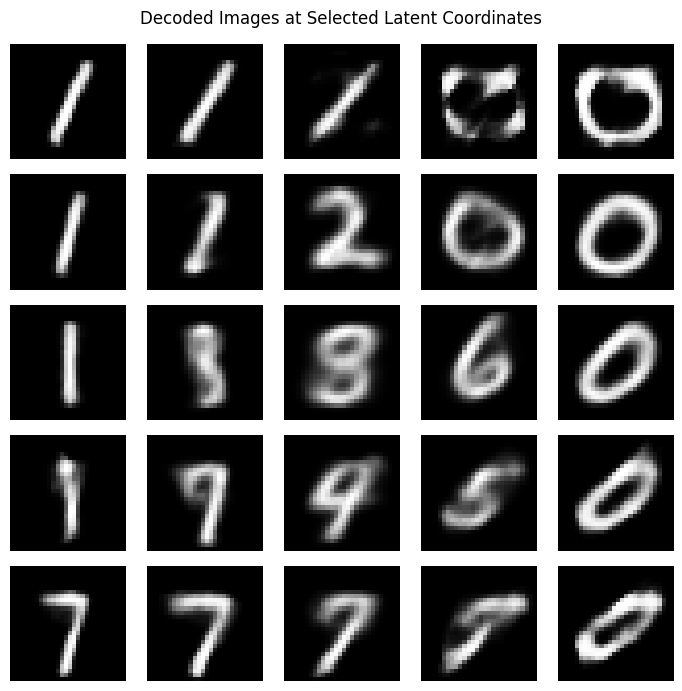

In [ ]:
values = np.linspace(-3, 3, 5)
coords = [[x, y] for y in reversed(values) for x in values]
z = torch.tensor(coords, dtype=torch.float32, device=device)

with torch.no_grad():
    decoded_small = vae.decode(z).cpu().numpy()

decoded_small = decoded_small.reshape(5, 5, 28, 28)

fig, axes = plt.subplots(5, 5, figsize=(7, 7))
for r in range(5):
    for c in range(5):
        axes[r, c].imshow(decoded_small[r, c], cmap="gray")
        axes[r, c].axis("off")

plt.suptitle("Decoded Images at Selected Latent Coordinates")
plt.tight_layout()
plt.show()

## 10. Written Observations

**Do similar digits form clusters?**  
Inspect the scatter plot and identify whether examples of the same digit tend to occupy nearby regions. Similar handwritten shapes may appear close together.

**Are the clusters clearly separated?**  
Some digits may form distinct groups, while visually similar digits can overlap. State which groups appear separated or overlapping in your actual plot.

**How do generated digits change through the latent space?**  
Moving gradually through the grid should cause gradual changes in stroke shape, thickness, orientation, and sometimes digit identity.

**Does the transition appear smooth?**  
A VAE encourages a continuous latent representation, so neighboring coordinates often produce related images rather than abrupt unrelated changes. The exact smoothness depends on training.

> Replace these general observations with specific observations from your actual plots before submitting.

## 11. Conclusion

The VAE compresses MNIST images into a structured 2D latent representation and reconstructs images from sampled latent vectors. The scatter plot shows how digit representations are arranged, while decoding points across the latent space demonstrates whether the learned representation changes smoothly. Reconstruction loss measures how well the model reproduces images, while KL-divergence regularizes the latent distribution toward a standard normal distribution.

## 12. Submission Checklist

- [x] MNIST dataset
- [x] VAE implementation
- [x] 2D latent space
- [x] 20 training epochs
- [x] Reconstruction loss recorded
- [x] KL-divergence loss recorded
- [x] Loss graph
- [x] 2D latent-space scatter plot colored by digits 0–9
- [x] Decoded grid using latent coordinates from approximately −3 to +3
- [x] Short written observations